# Experiment 3: LightGBM Model for YouTube Comment Sentiment Analysis

This notebook mirrors the structure of `experiment_1_baseline_model.ipynb` (which trained a
`RandomForestClassifier`) and `experiment_2_model_comparison.ipynb` (Logistic Regression,
Naive Bayes, Linear SVM, XGBoost), but trains a **LightGBM** (`LGBMClassifier`) model — a
gradient-boosted tree model not used in either earlier notebook — on the same
`CountVectorizer` features, and logs the run to MLflow via DagsHub.

In [1]:
# Install any missing dependencies (uncomment if needed)
# %pip install mlflow dagshub lightgbm scikit-learn pandas numpy matplotlib seaborn

In [2]:
import mlflow
import dagshub

# Same DagsHub-tracked repo used in the earlier experiment notebooks
dagshub.init(repo_owner="MitadruMridha05", repo_name="Youtube_Sentiment_Analysis", mlflow=True)

remote_server_uri = "https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow"
mlflow.set_tracking_uri(remote_server_uri)

c:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accessing as MitadruMridha05

Initialized MLflow to track repo "MitadruMridha05/Youtube_Sentiment_Analysis"

Repository MitadruMridha05/Youtube_Sentiment_Analysis initialized!

In [3]:
import numpy as np
import pandas as pd

## Load data

Update `DATA_PATH` to point at your local copy of `youtube_comments_cleaned_final.csv`
(the same file used in the earlier experiment notebooks).

In [4]:
DATA_PATH = r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts\youtube_comments_cleaned_final.csv"

df = pd.read_csv(DATA_PATH)
df.shape

(100000, 2)

In [5]:
df["Sentiment"].value_counts()

Sentiment
-1    33475
 1    33473
 0    33052
Name: count, dtype: int64

In [6]:
import mlflow.lightgbm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from lightgbm import LGBMClassifier

## Feature extraction

Same `CountVectorizer` settings as the earlier notebooks (`max_features=10000`) so this
model is comparable to the baseline and the other models.

In [7]:
vectorizer = CountVectorizer(max_features=10000)

df["CommentText"] = df["CommentText"].fillna("")
x = vectorizer.fit_transform(df["CommentText"]).toarray()
y = df["Sentiment"]

In [8]:
mlflow.set_tracking_uri(remote_server_uri)

In [9]:
mlflow.set_experiment("LightGBM_model")

2026/09/13 00:12:55 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM_model' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/4916ee22027c4bfa82ed07e69cb61c72', creation_time=1789238575588, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1789238575588, lifecycle_stage='active', name='LightGBM_model', tags={}, trace_location=None, workspace='default'>

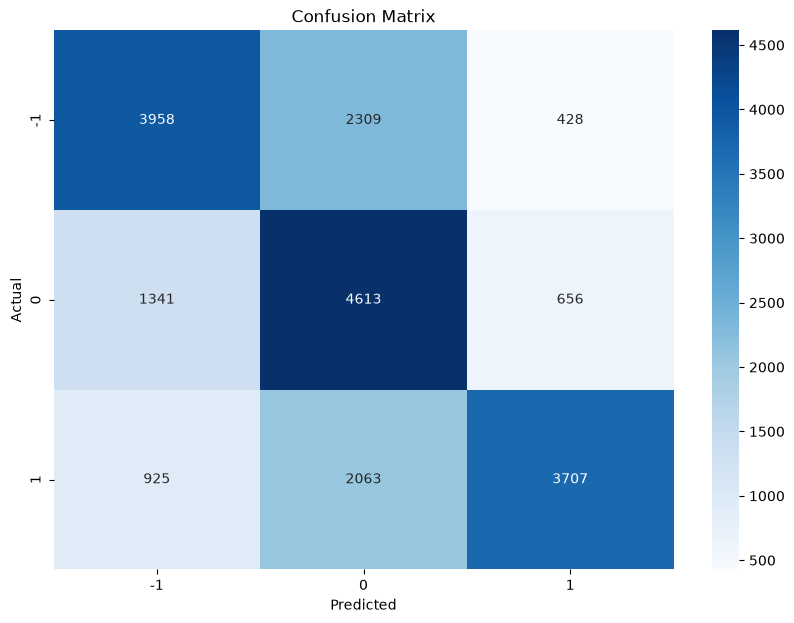

<Figure size 640x480 with 0 Axes>

2026/09/13 00:14:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run illustrious-frog-453 at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/3/runs/5d488eba343740d7aeb440a1d706f46a
🧪 View experiment at: https://dagshub.com/MitadruMridha05/Youtube_Sentiment_Analysis.mlflow/#/experiments/3
LightGBM model training completed and logged to MLflow.
Accuracy: 0.6139


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

with mlflow.start_run():
    #Log a description for the run
    mlflow.set_tag("model_type", "LGBMClassifier")
    mlflow.set_tag("experiment", "lightgbm_model")
    mlflow.set_tag("mlflow_runName", "LightGBM_model")

    #Add a description
    mlflow.set_tag("description", "LightGBM model for sentiment analysis on YouTube comments.")

    #Log parameters for vectorizer and model
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    #Log LightGBM parameters
    n_estimators = 100
    max_depth = 15
    learning_rate = 0.1
    num_leaves = 31

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("num_leaves", num_leaves)

    #initialize and train the LightGBM model
    lgbm_model = LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        random_state=42,
        verbosity=-1,
    )
    lgbm_model.fit(x_train, y_train)

    #Make predictions
    y_pred = lgbm_model.predict(x_test)

    #Log metrics
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if label not in ["accuracy", "macro avg", "weighted avg"]:
            for metric_name, metric_value in metrics.items():
                mlflow.log_metric(f"{label}_{metric_name}", metric_value)

    #Plot confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    #Save and log the confusion matrix plot
    import os
    artifact_dir = r"C:\Users\mitad\OneDrive\Documents\coding_maxxing\sentiment_analysing_project\artifacts"
    os.makedirs(artifact_dir, exist_ok=True)
    artifact_path = os.path.join(artifact_dir, "confusion_matrix_lightgbm.png")

    # Save the confusion matrix
    plt.savefig(artifact_path, bbox_inches="tight")
    plt.show()

    # Log the saved artifact to MLflow
    mlflow.log_artifact(artifact_path, artifact_path="plots")

    # Log the trained model
    mlflow.lightgbm.log_model(lgbm_model, "lightgbm_model")

print("LightGBM model training completed and logged to MLflow.")
print(f"Accuracy: {accuracy:.4f}")

## Next steps

- Compare this run's accuracy/F1 against the baseline Random Forest run and the models in
  `experiment_2_model_comparison.ipynb` inside the MLflow UI.
- Try tuning LightGBM's `num_leaves`, `max_depth`, and `learning_rate` (e.g. with
  `GridSearchCV` / `RandomizedSearchCV` or `optuna`) if this run looks promising.
- Consider TF-IDF features instead of `CountVectorizer` as a further variant.